In [165]:
# step 1  --> Data Collection(import pandas,read CSV,df.head(),df.shape,df.columns)
# step 2  --> Data Cleaning
# step 3  --> Exploratory Data Analysis(EDA)
# step 4  --> Feature Engineering
# step 5  --> Model Selection
# step 6  --> Model Training
# step 7  --> Model Evaluation
# step 8  --> Model Deployment

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Step 1 --> Data Collection
df = pd.read_csv("Housing.csv") 
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,NaN,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [197]:
df.shape

(545, 13)

In [198]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [199]:
# Step 2 --> Data Cleaning
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            1
furnishingstatus    0
dtype: int64

In [200]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          544 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [201]:
df['prefarea'].value_counts(dropna=False)

prefarea
no     417
yes    127
NaN      1
Name: count, dtype: int64

In [202]:
df['prefarea'] = df['prefarea'].fillna(df['prefarea'].mode()[0])



In [203]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [204]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


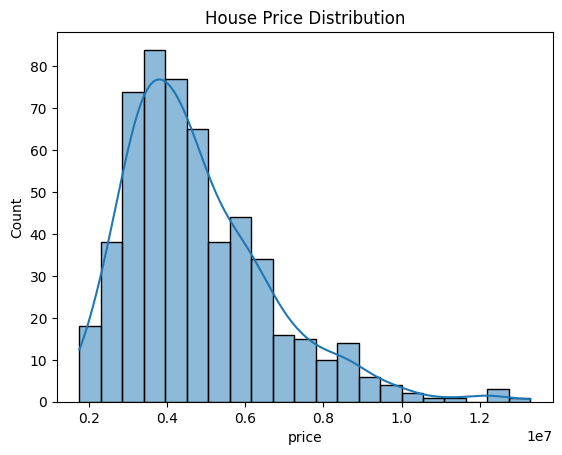

In [205]:
# Step : 3(EDA)

sns.histplot(df['price'], kde=True)
plt.title("House Price Distribution")
# plt.xlabel("Price")
# plt.ylabel("Frequency")
plt.show()

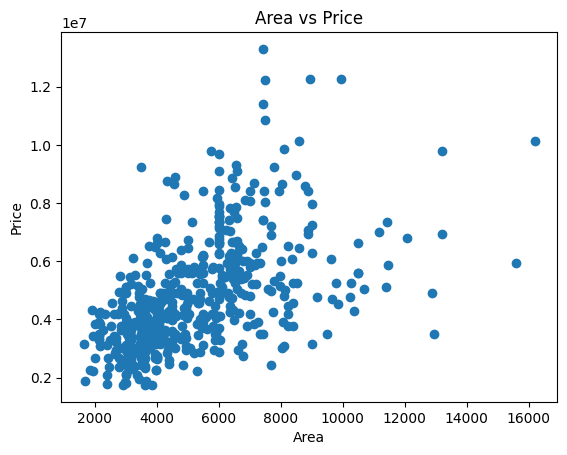

In [206]:
plt.scatter(df['area'], df['price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

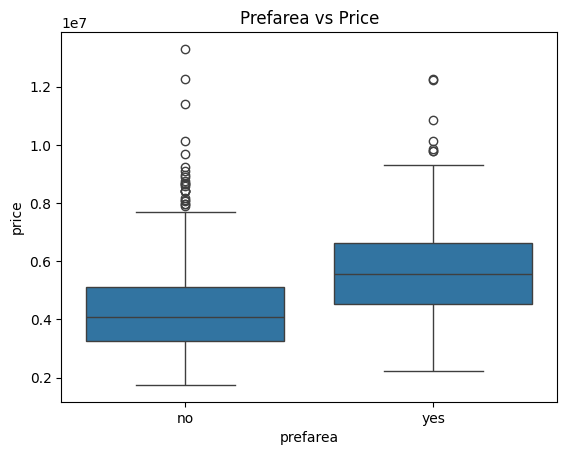

In [207]:
sns.boxplot(x=df['prefarea'], y=df['price'])
plt.title("Prefarea vs Price")
plt.show()

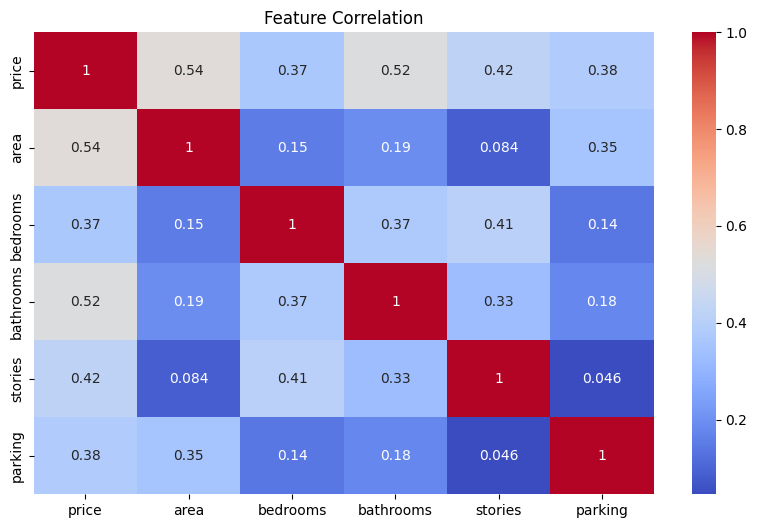

In [208]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [209]:

# We apply Feature Engineering bcz  i need  a better performance of model
df['area_per_bedroom'] = df['area'] / df['bedrooms']
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

In [210]:
df.dtypes

price                 int64
area                  int64
bedrooms              int64
bathrooms             int64
stories               int64
mainroad             object
guestroom            object
basement             object
hotwaterheating      object
airconditioning      object
parking               int64
prefarea             object
furnishingstatus     object
area_per_bedroom    float64
total_rooms           int64
dtype: object

In [211]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [212]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,area_per_bedroom,total_rooms
0,13300000,7420,4,2,3,1,0,0,0,1,2,0,furnished,1855.0,6
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,2240.0,8
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,3320.0,5
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,1875.0,6
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,1855.0,5


In [213]:

# (One-Hot Encoding )Apply  because   furnishingstatus   are 3 category thats why we apply One -Hot Encoding
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [214]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,area_per_bedroom,total_rooms,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,0,1855.0,6,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2240.0,8,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,3320.0,5,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1875.0,6,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1855.0,5,False,False


In [215]:
# Step 5 ----> 
# We will do 4 things:
# 1. Split data (X, y)
# 2. Train model
# 3. Predict
# 4. Evaluate



In [223]:
# X = df.drop('price', axis=1)
# y = df['price']
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

X = df[features]
y = df['price']

In [224]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [225]:

# Apply Scalling bcz model gets biased toward large numbers
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [226]:
# We Will used Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [227]:
y_pred = model.predict(X_test)

In [228]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 2293867305607.654
R2 Score: 0.5461795575480068


In [229]:
import joblib
joblib.dump(model, 'house_price_model.pkl')
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']